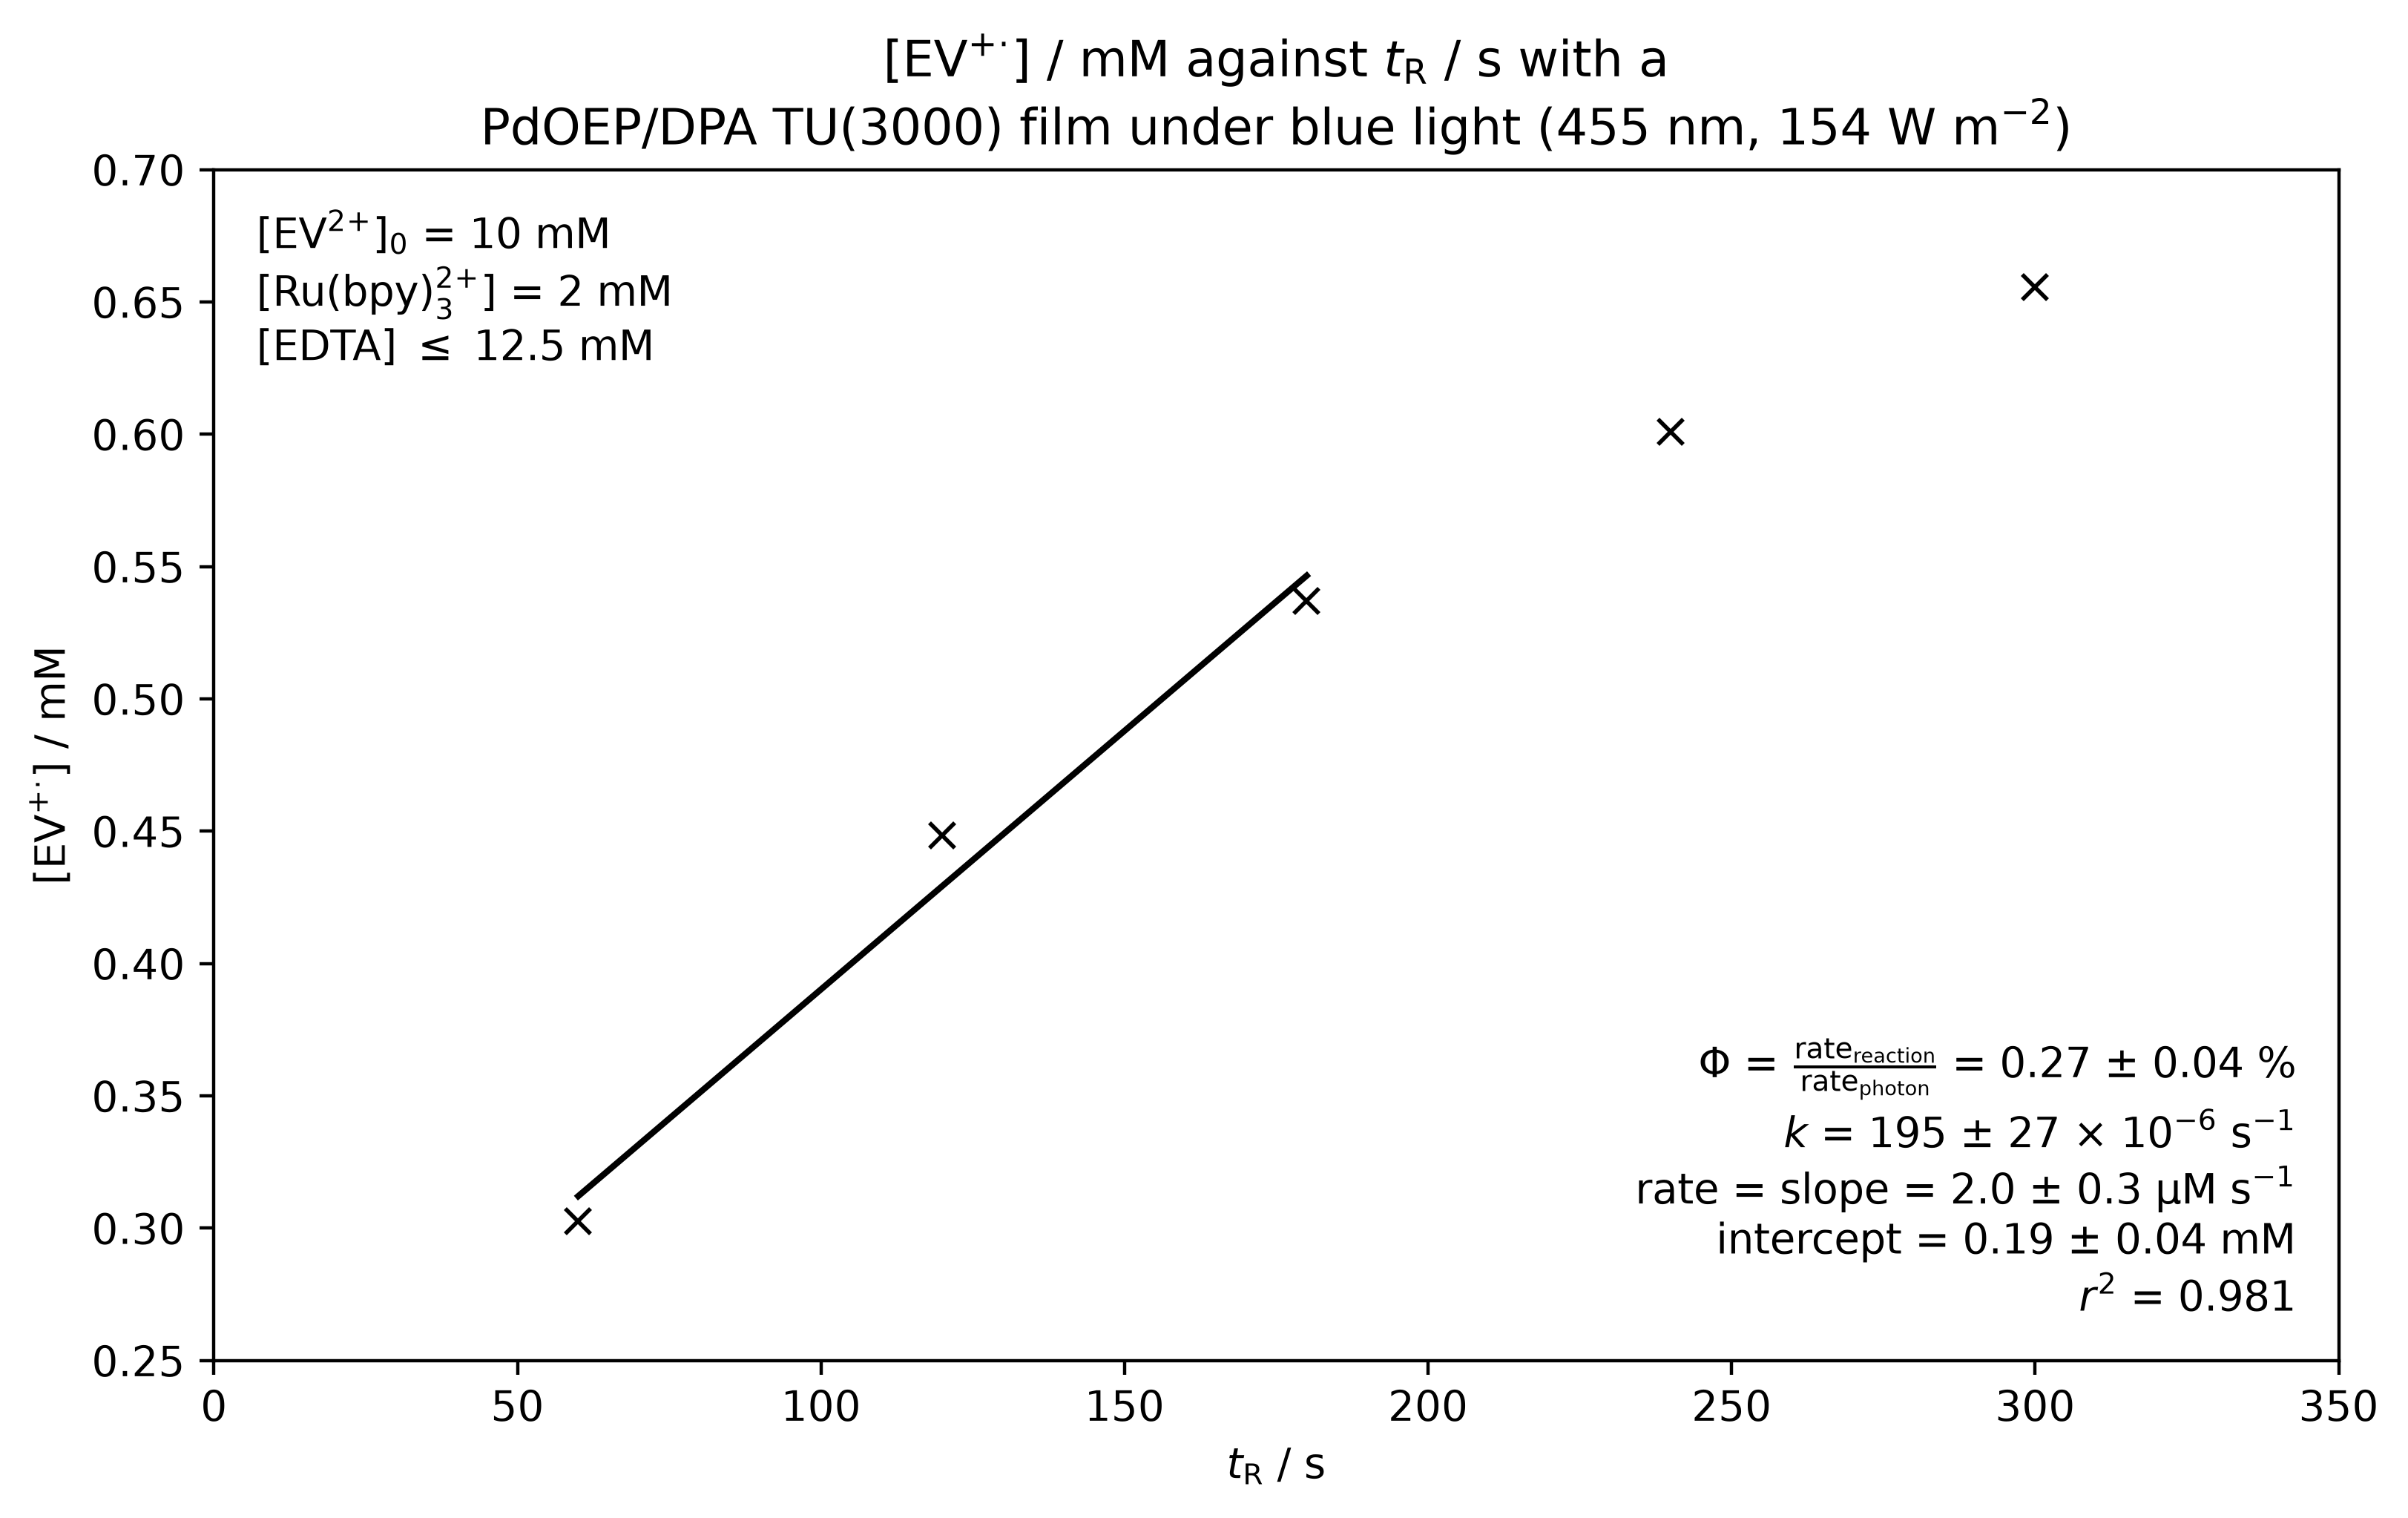

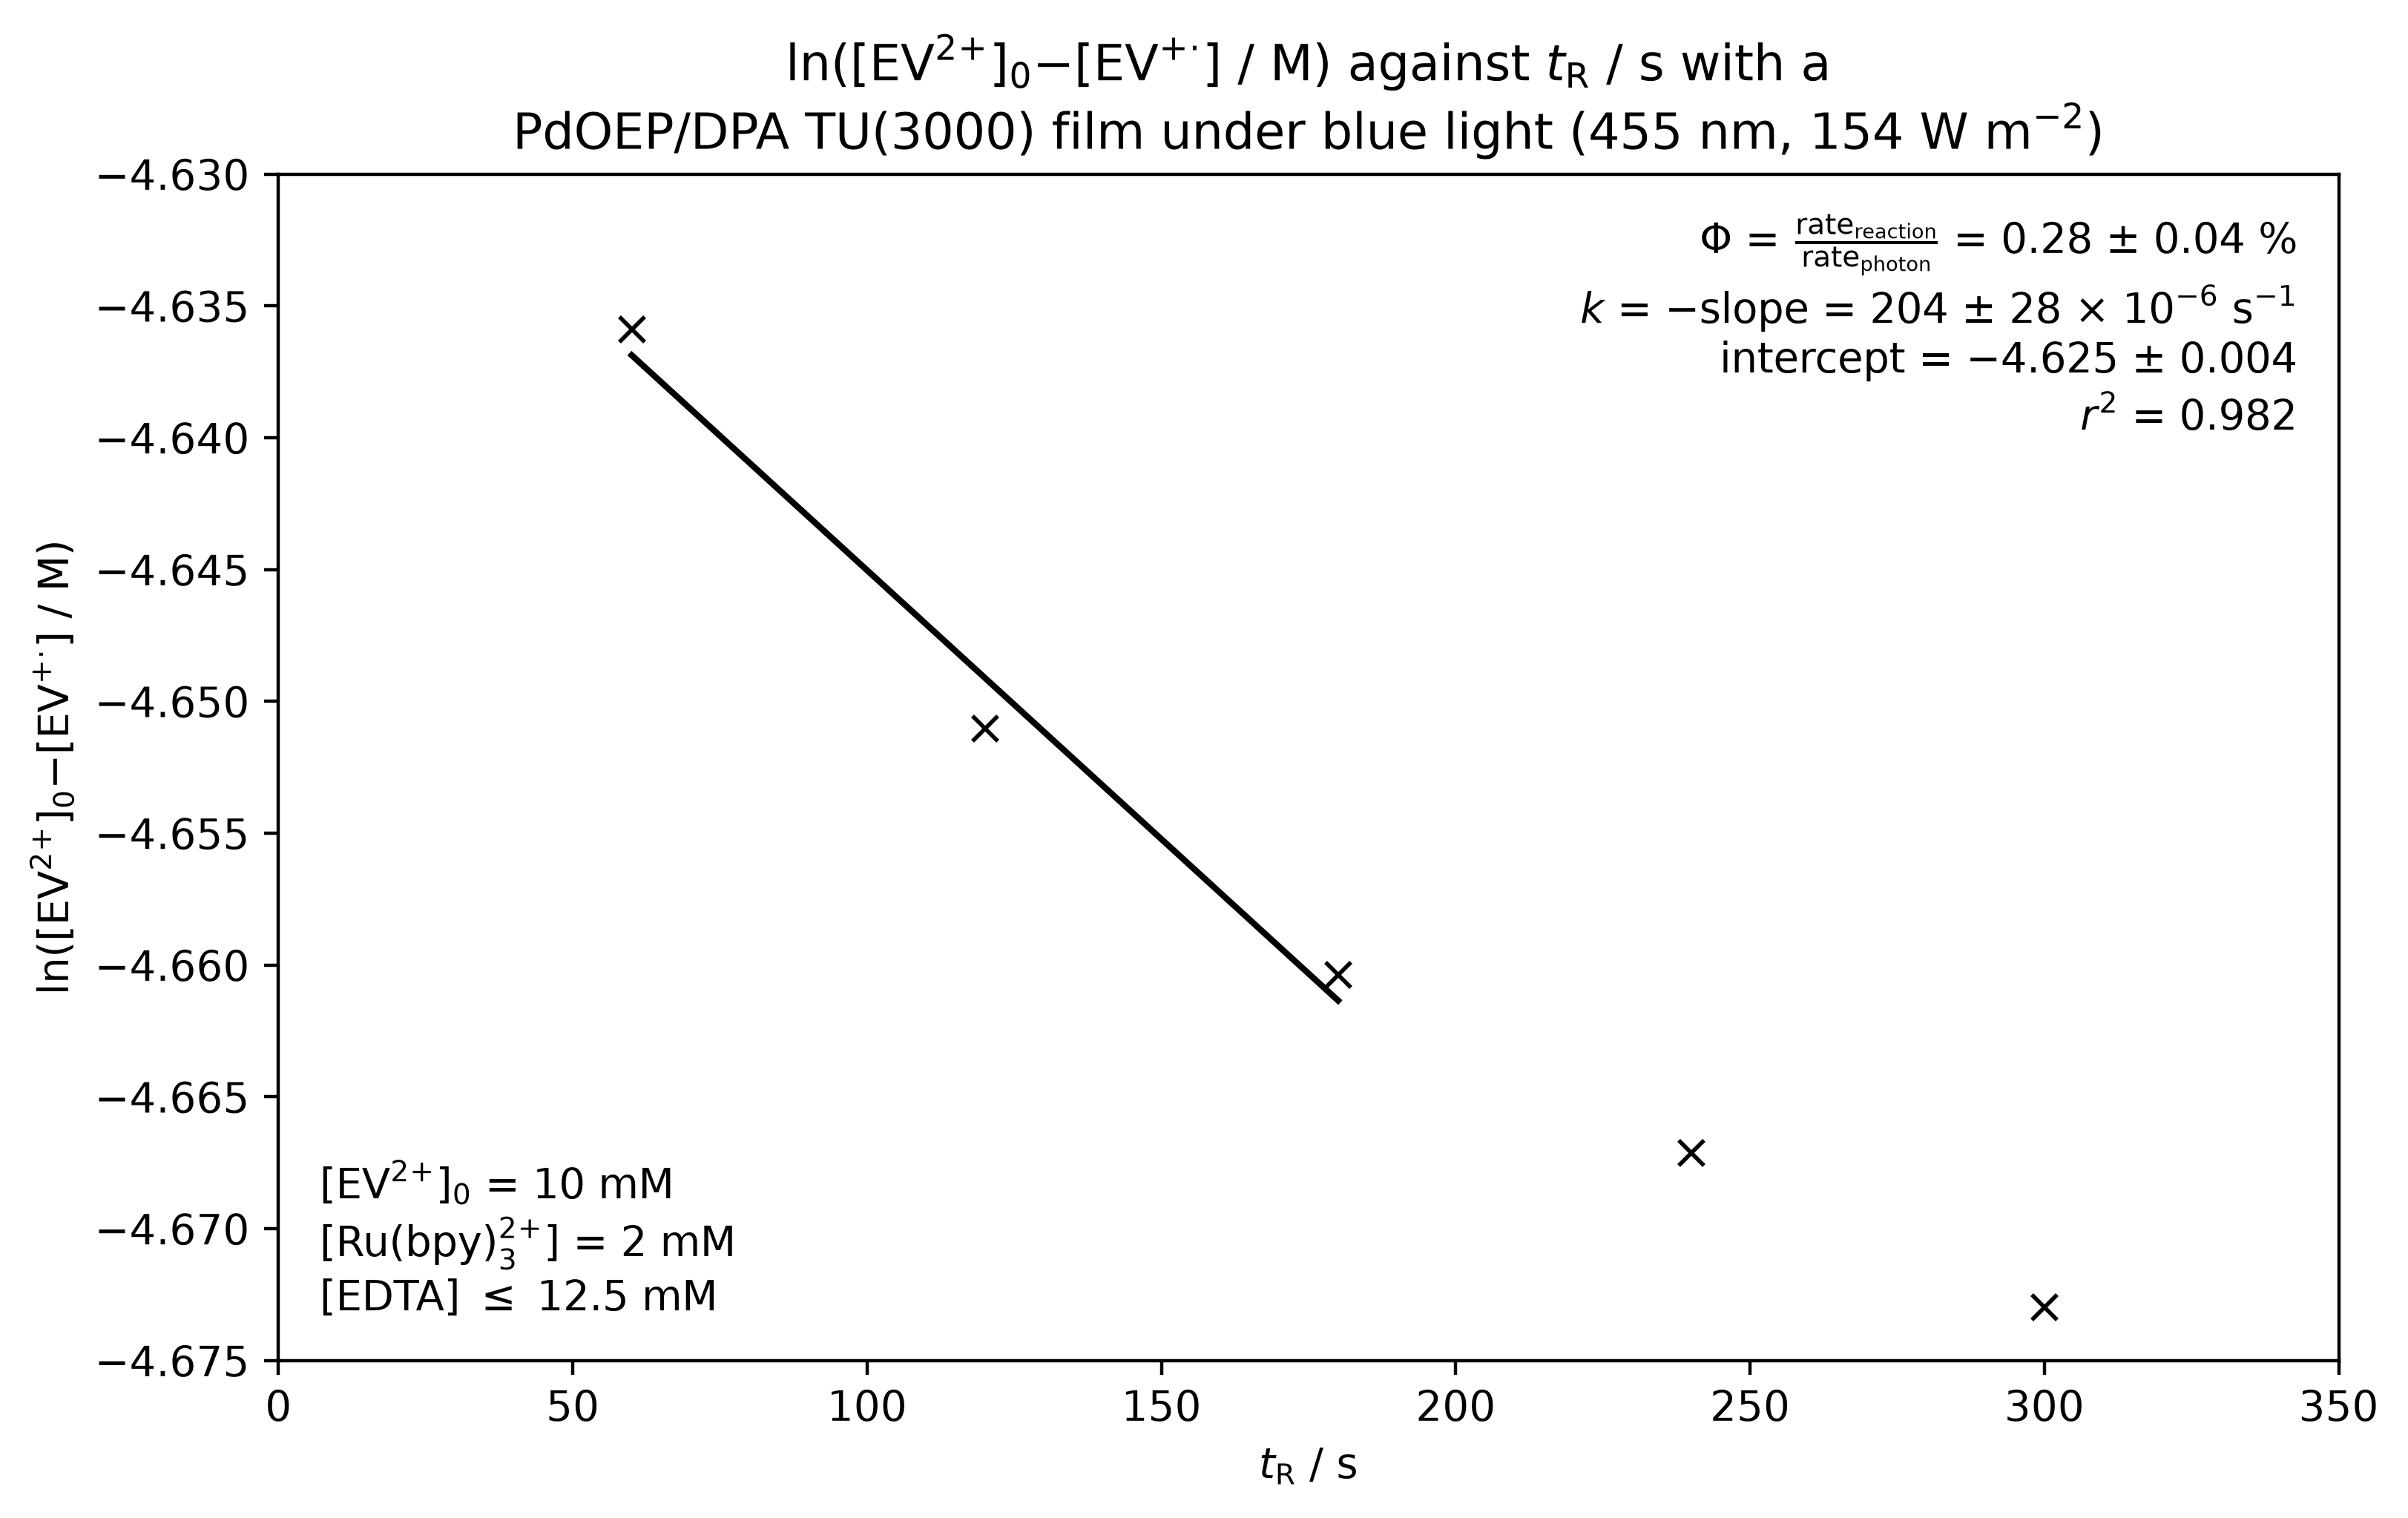

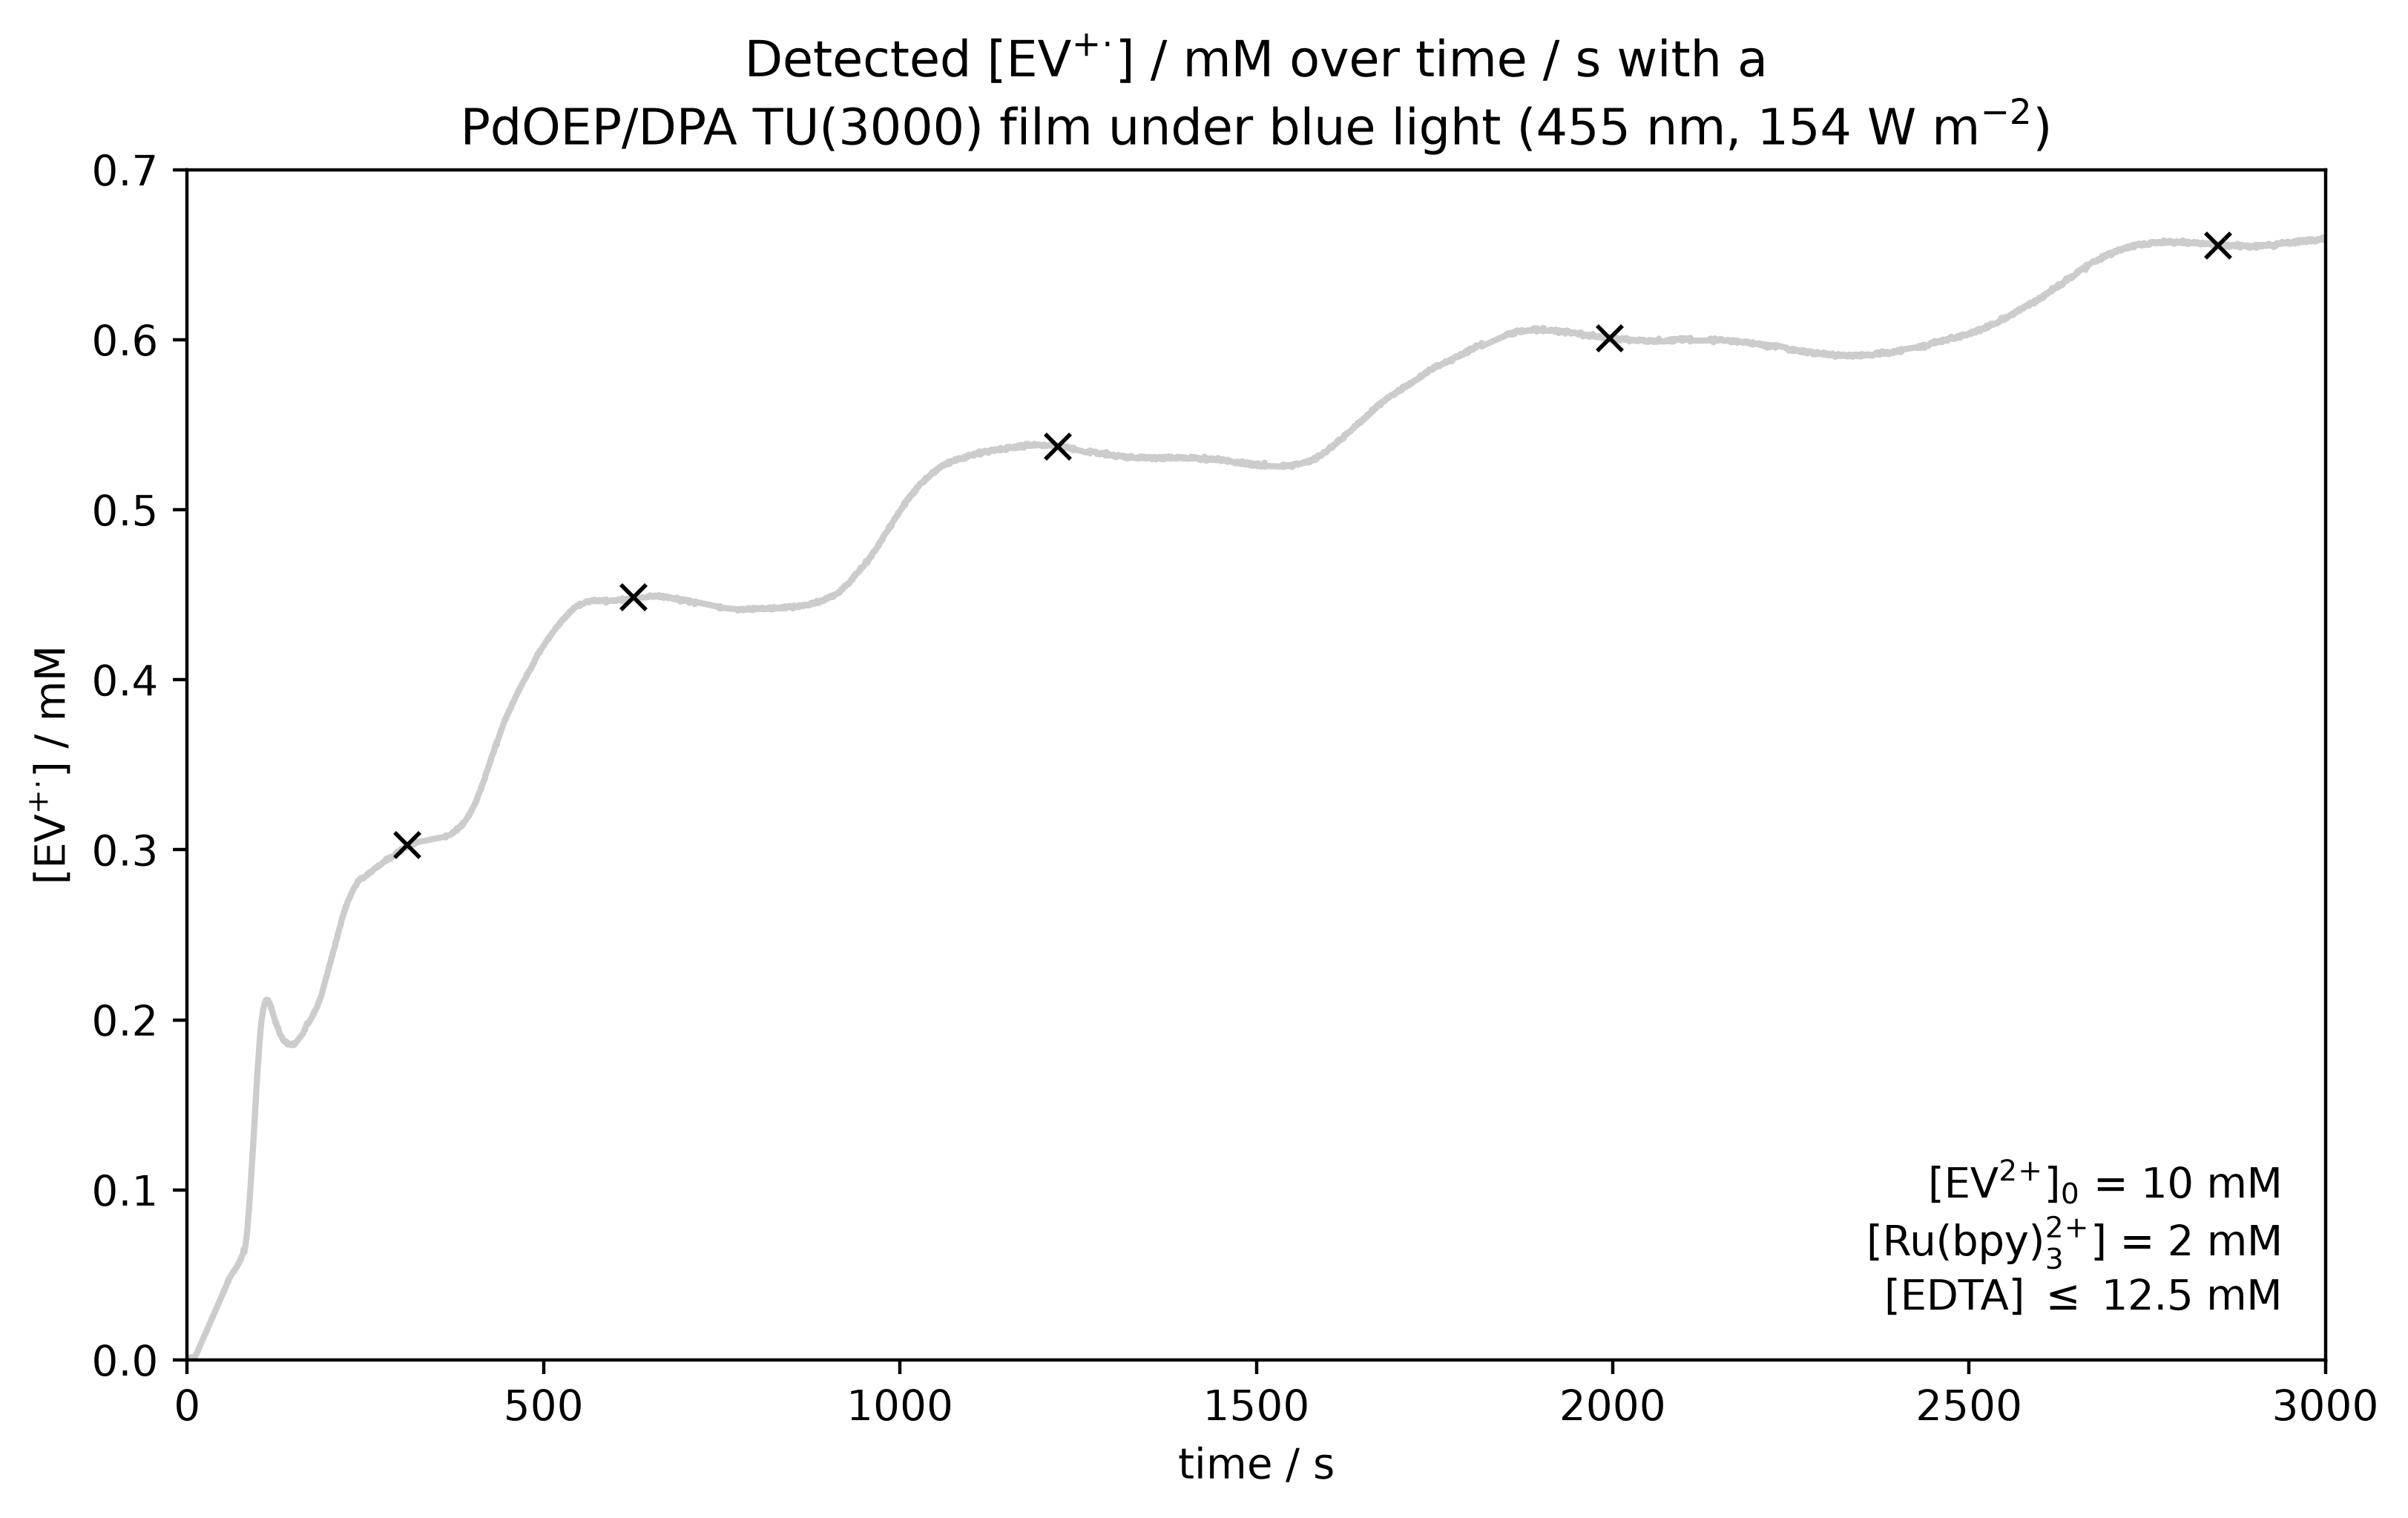

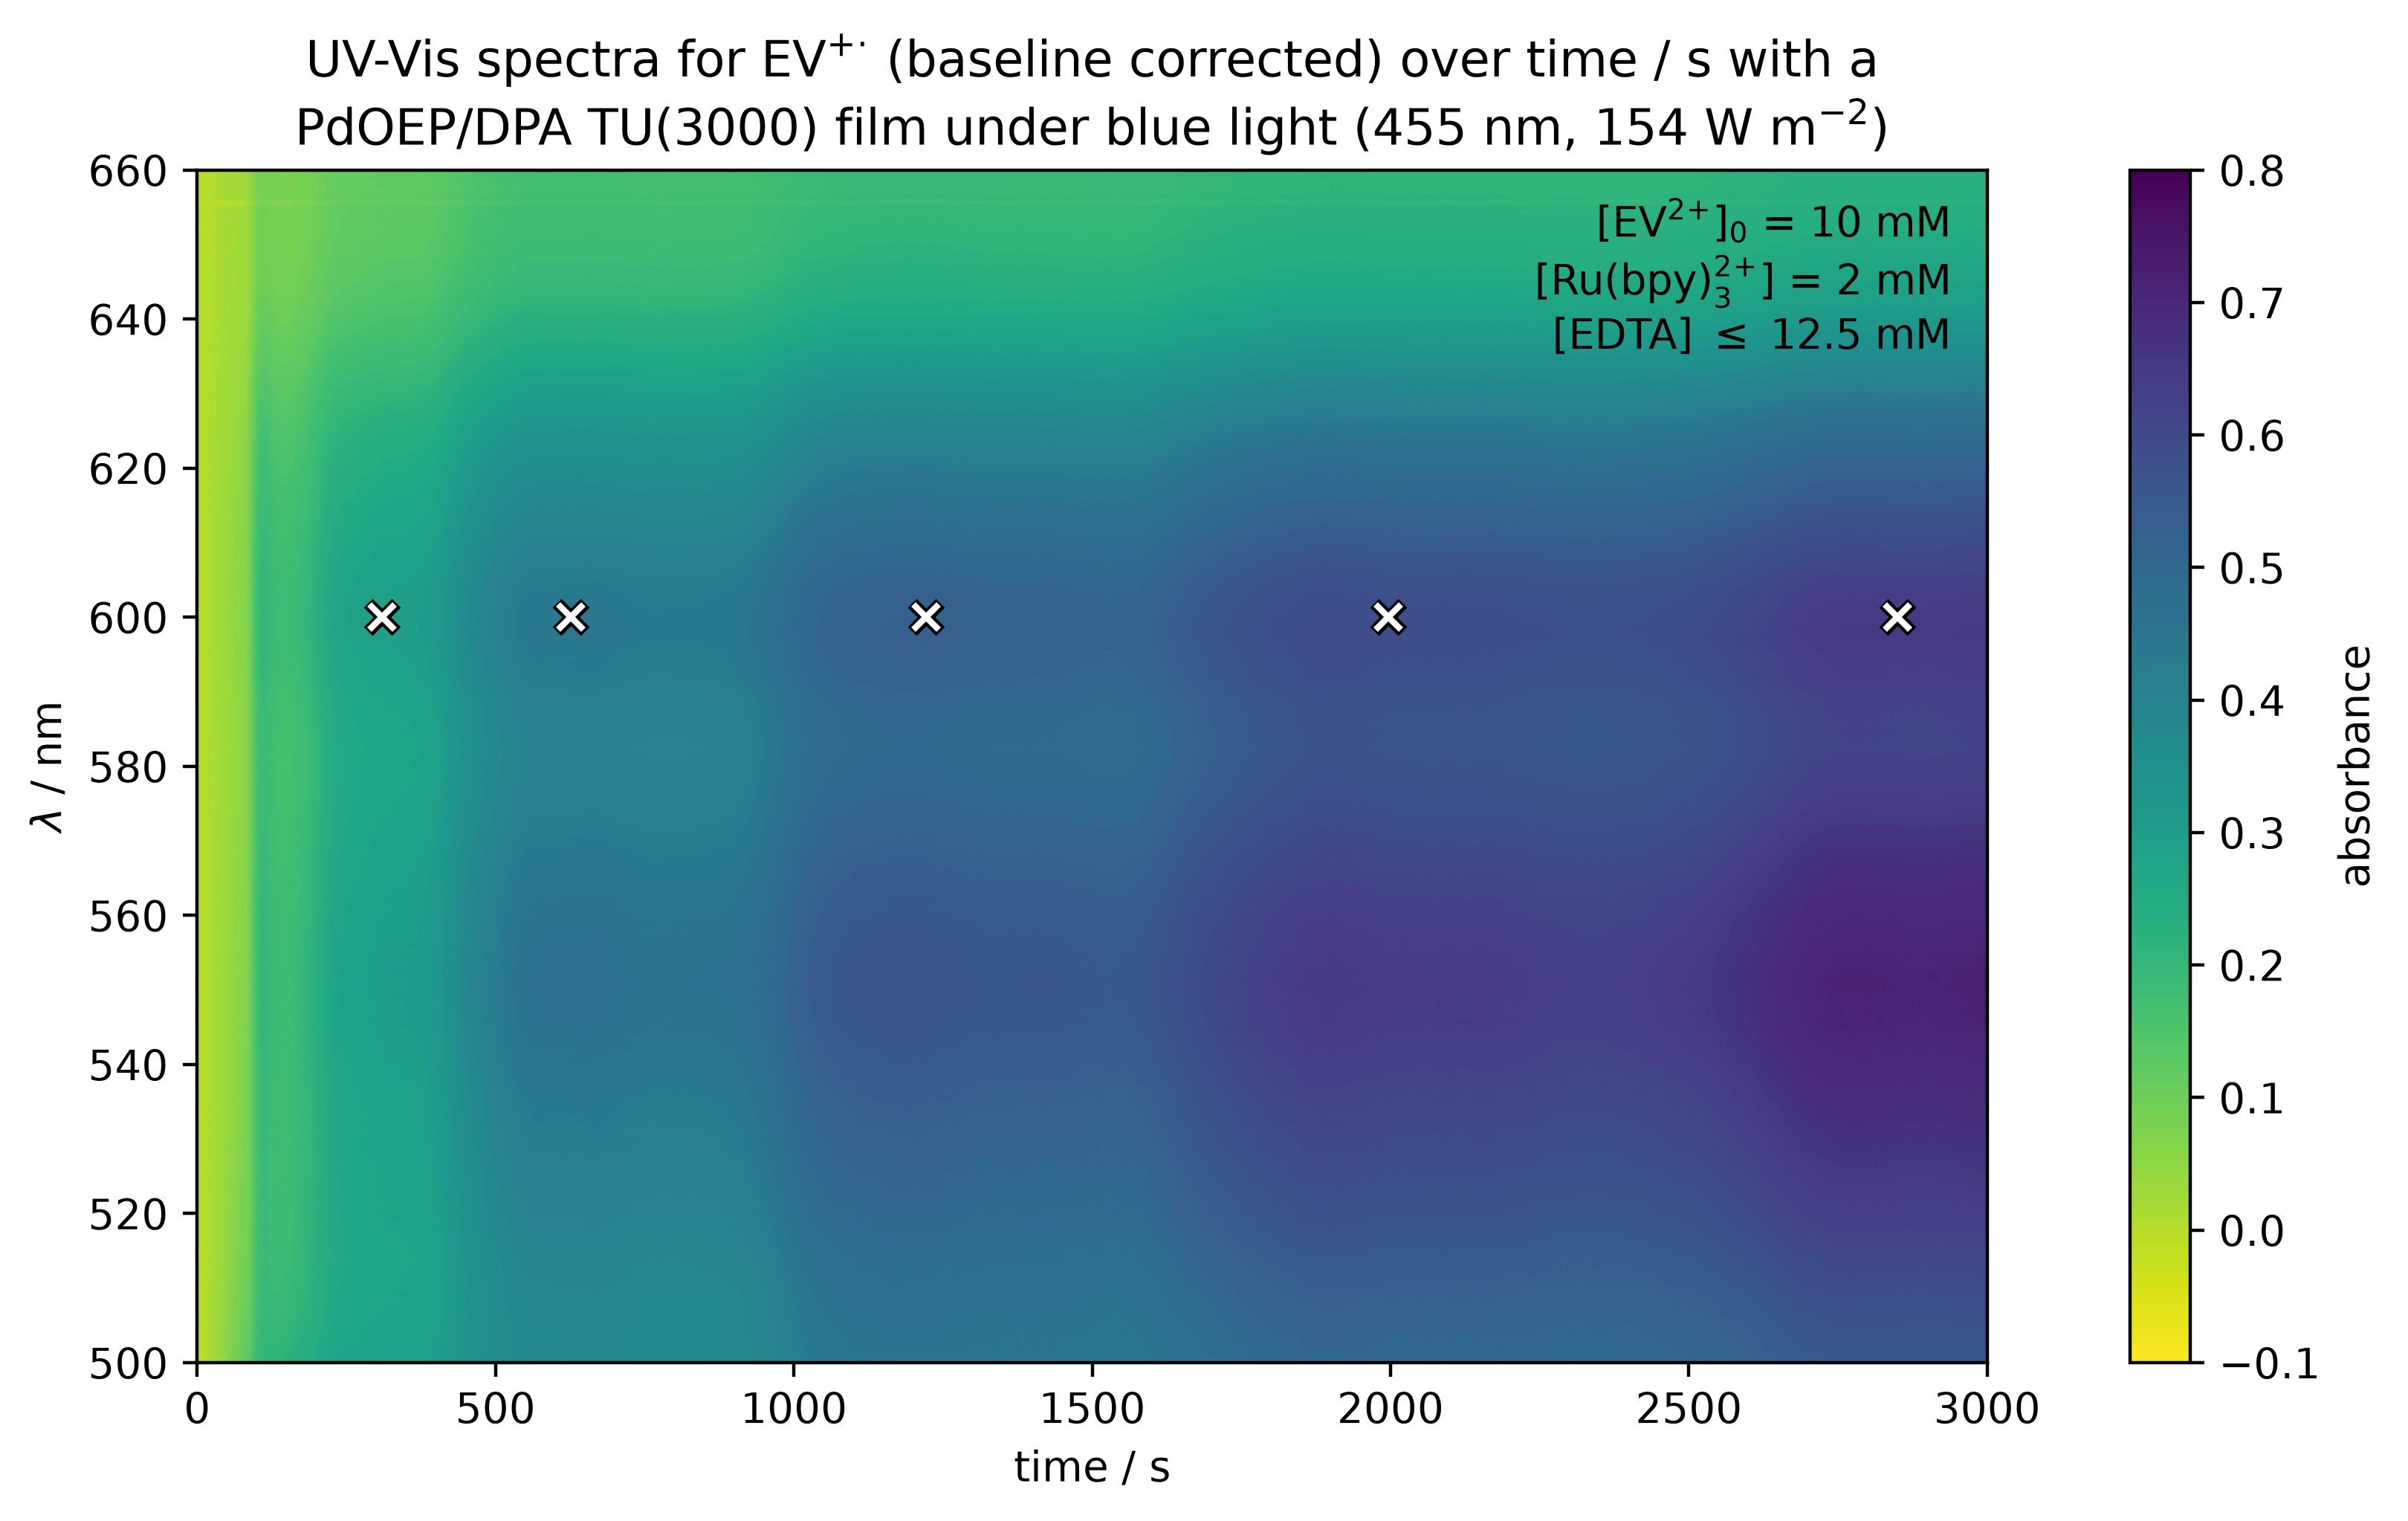

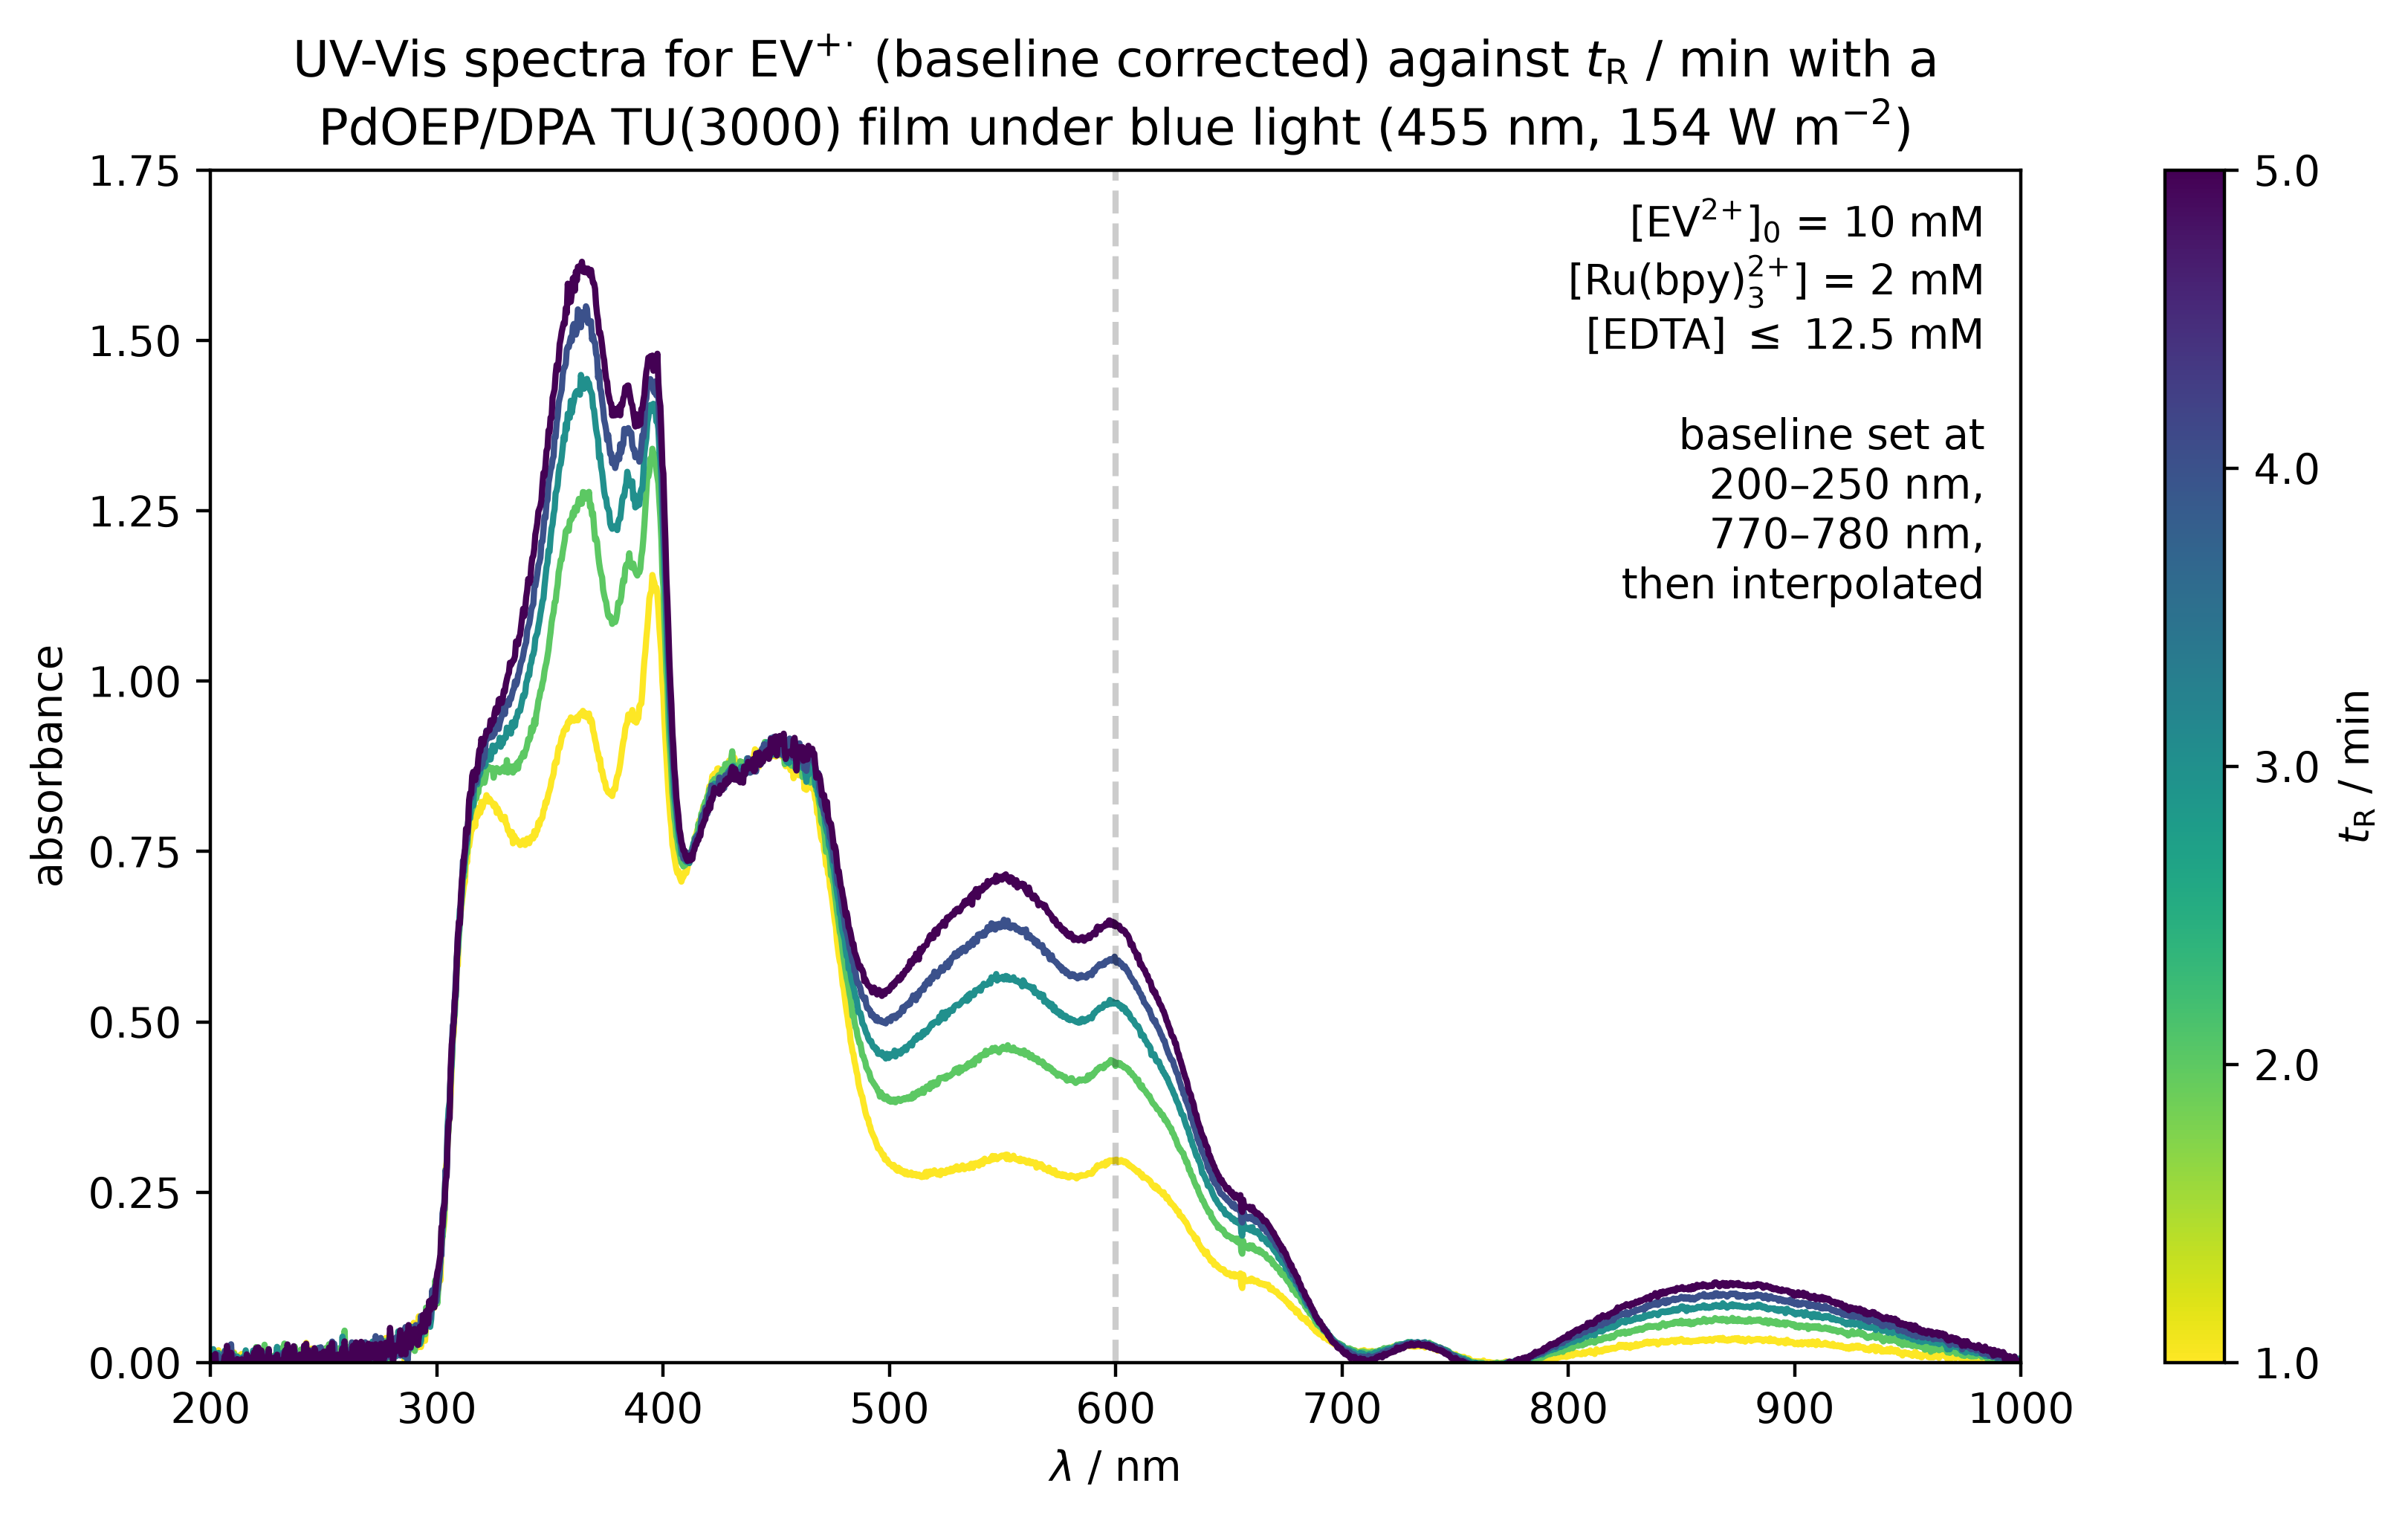

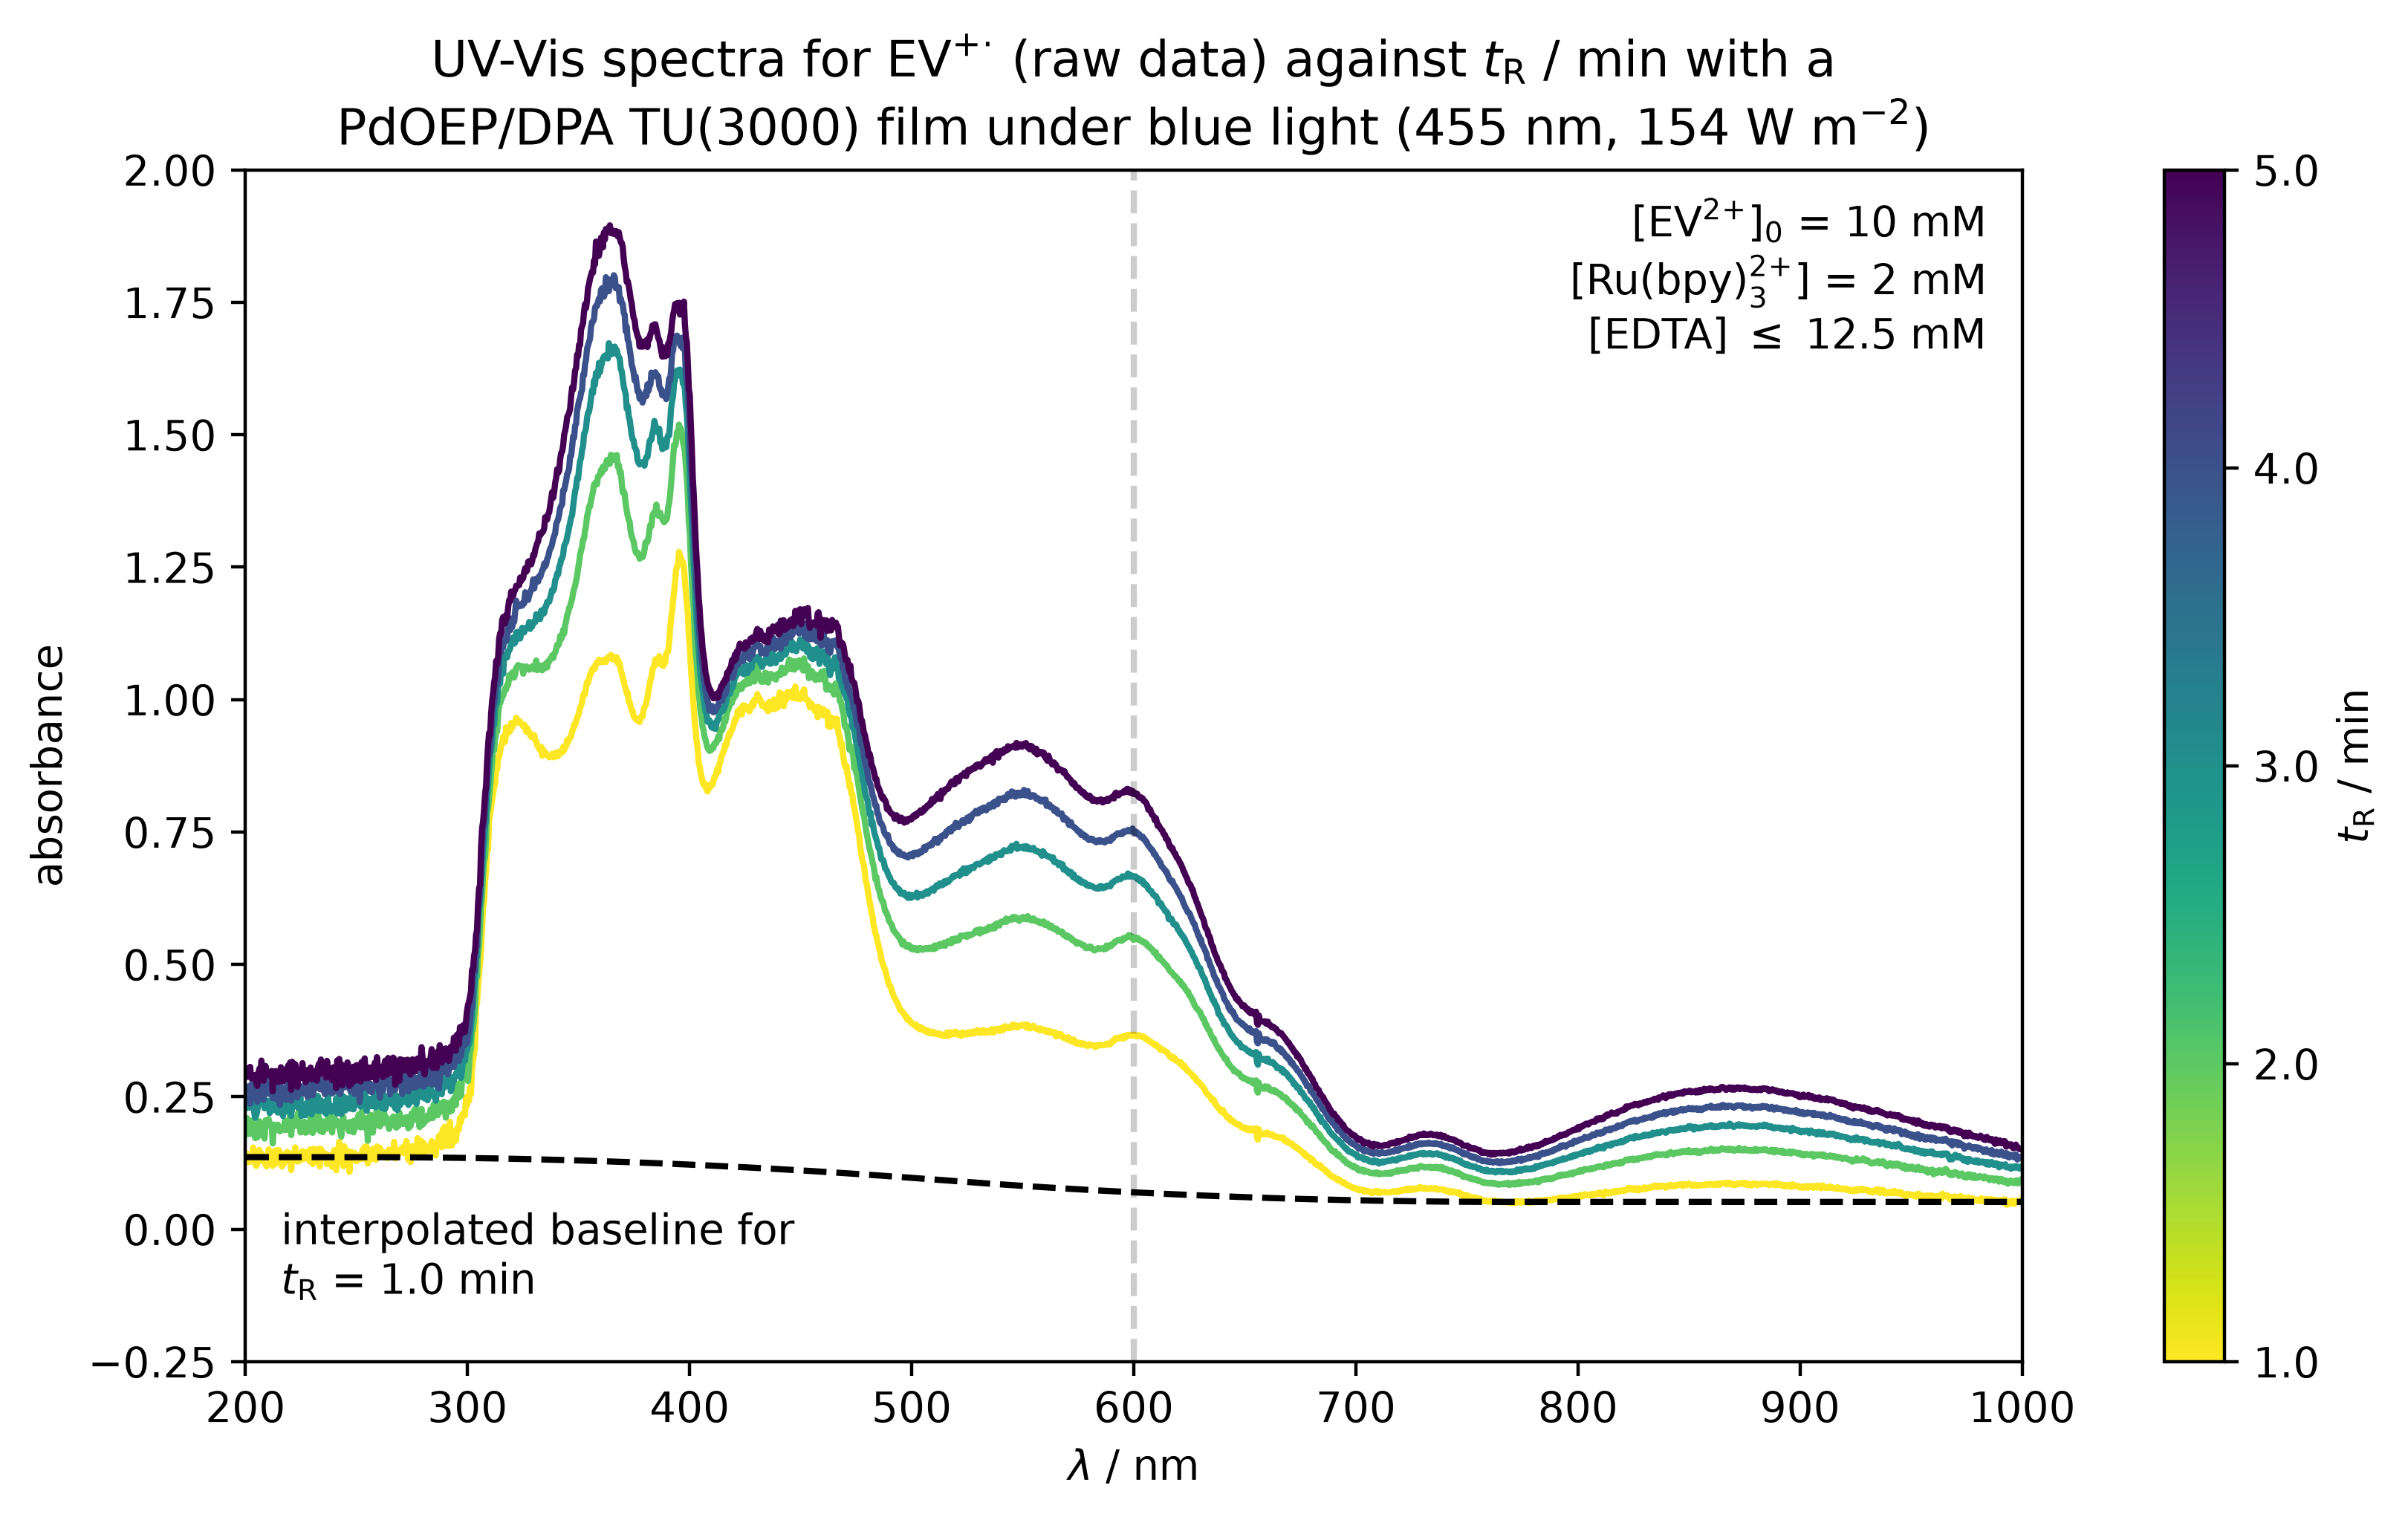

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS, X
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Blue 455 nm irradiation at 10.9 mW.

V([Ru(bpy)3]2+, 12 mM, pH 7 buffer) = 500 ul (2 mM)
V(XV2+, 30 mM, pH 7 buffer) = 1000 ul (10 mM)
V(EDTA, <25 mM saturated, pH 7 buffer) = 1500 ul (<12.5 mM)
"""

data = '260803_Rubpy_EV_EDTA_TU(3000)_PdOEP_DPA_Blue_Flow' # data folder name

tRs = np.arange(60, 5*60+1, 60) # residence times/s for 1-5 min in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
points[0] += 100 # add 100 s to the first record point
points[-1] -= 100 # minus 100 s from the last record point
start = "17-00-00-000" # recorded start time

c0 = 10e-3 # initial EV2+ concentration
details = f'{X['RU']} = 2 mM\n[EDTA] $\\leq$ 12.5 mM' # concentrations of other reagents

x = 'EVrubpy'
film = 'PdOEP/DPA TU(3000)' # 24/10/2025 100 mM PdOEP 100 mM DPA
light = 'blue'
wavelength = 455e-9 # m
power = 10.9e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power)
expt.concvstimeplot(r2threshold=0.98)
expt.concvstimeplot(ln=True, r2threshold=0.98)
expt.detectorconcplot(duration=3000)
expt.detectorspectrumplot(duration=3000)
expt.spectrumvstimeplot()